from IPython.display import display, HTML

display(HTML("""
<div style="background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
            padding: 40px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
    <h1 style="color: #00d2ff; font-size: 2.5em; margin-bottom: 10px;">
        🚲 Part 1 — Regression
    </h1>
    <h3 style="color: #a8dadc; font-size: 1.3em; margin-bottom: 10px;">
        London Bike Sharing — Ride Count Prediction
    </h3>
    <p style="color: #778ca3; font-size: 1em;">
        📦 Dataset: <a href="https://www.kaggle.com/datasets/hmavrodiev/london-bike-sharing-dataset"
        style="color:#00d2ff;">Kaggle — London Bike Sharing (TfL Open Data)</a>
    </p>
    <p style="color: #778ca3;">
        🎯 Objective: Predict the <b style="color:#00d2ff;">number of bike rides per hour</b>
        using weather, time, and calendar features.
    </p>
</div>
"""))

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.16.2


display(HTML("""
<div style="background: linear-gradient(90deg, #e94560, #0f3460);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">📊 Step 1: Load and Explore the Dataset</h2>
</div>
"""))

In [25]:
df = pd.read_csv('london_merged.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (17414, 10)

Column names: ['timestamp', 'cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']

Data types:
 timestamp           str
cnt               int64
t1              float64
t2              float64
hum             float64
wind_speed      float64
weather_code    float64
is_holiday      float64
is_weekend      float64
season          float64
dtype: object

First 5 rows:


,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [26]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468091,11.520836,72.324954,15.913063,2.722752,0.022051,0.285403,1.492075
std,1085.108068,5.571818,6.615145,14.313186,7.894570,2.341163,0.146854,0.451619,1.118911
min,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,7860.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000


In [27]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

Total missing: 0


display(HTML("""
<div style="background: linear-gradient(90deg, #11998e, #38ef7d);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">🔧 Step 2: Preprocessing & Feature Engineering</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">
        Parsing timestamp → hour, day_of_week, month | Target: <b>cnt</b>
    </p>
</div>
"""))

Features:
['cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season', 'hour', 'day_of_week', 'month']

Target variable (cnt) stats:
count    17414.000000
mean      1143.101642
std       1085.108068
min          0.000000
25%        257.000000
50%        844.000000
75%       1671.750000
max       7860.000000
Name: cnt, dtype: float64


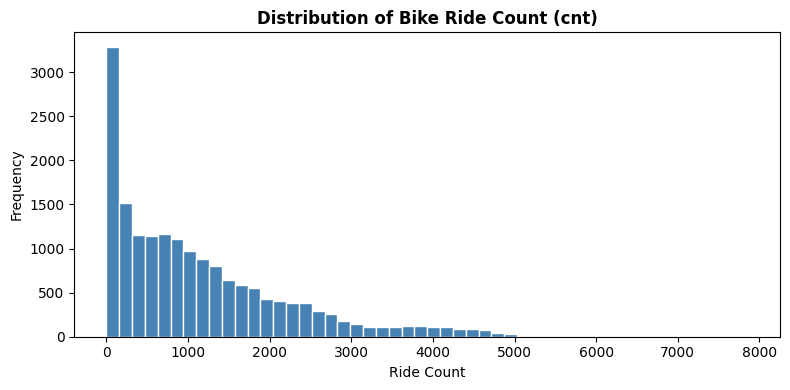

In [28]:
# Parse timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Drop timestamp — not needed as a raw feature
df_model = df.drop(columns=['timestamp'])

print("Features:")
print(df_model.columns.tolist())
print("\nTarget variable (cnt) stats:")
print(df_model['cnt'].describe())

# Plot target distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_model['cnt'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Bike Ride Count (cnt)', fontweight='bold')
ax.set_xlabel('Ride Count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

display(HTML("""
<div style="background: linear-gradient(90deg, #8e2de2, #4a00e0);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">✂️ Step 3: Train / Test Split</h2>
    <p style="color: #ddd; margin: 8px 0 0 0;">
        80% training — 20% testing | random_state=42
    </p>
</div>
"""))

In [29]:
X = df_model.drop(columns=['cnt'])
y = df_model['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nTarget stats in training set:")
print(y_train.describe())

Training set: (13931, 11)
Test set:     (3483, 11)

Target stats in training set:
count    13931.000000
mean      1142.386835
std       1082.709728
min          0.000000
25%        260.000000
50%        846.000000
75%       1662.500000
max       7860.000000
Name: cnt, dtype: float64


display(HTML("""
<div style="background: linear-gradient(90deg, #f953c6, #b91d73);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🤖 Step 4: Train All 7 Models</h2>
    <p style="color: #ffd6f0; margin: 8px 0 0 0;">
        Linear | Lasso | Ridge | SVR | Decision Tree | Random Forest | Neural Network
    </p>
</div>
"""))

In [30]:
def evaluate_model(name, y_test, y_pred, train_time):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return {
        'Model': name,
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'R²': round(r2, 4),
        'Train Time (s)': round(train_time, 2)
    }

results = []
print("Helper function defined ✓")

Helper function defined ✓


In [31]:
results = []

# ── 1. Linear Regression ────────────────────────────────────────────
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate_model('Linear Regression', y_test, lr.predict(X_test), time.time()-t0))
print("1. Linear Regression done ✓")

# ── 2. Lasso ────────────────────────────────────────────────────────
t0 = time.time()
lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train, y_train)
results.append(evaluate_model('Lasso', y_test, lasso.predict(X_test), time.time()-t0))
print("2. Lasso done ✓")

lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
print(f"\nLasso: {(lasso_coefs != 0).sum()} features survived:")
print(lasso_coefs[lasso_coefs != 0])

# ── 3. Ridge ────────────────────────────────────────────────────────
t0 = time.time()
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
results.append(evaluate_model('Ridge', y_test, ridge.predict(X_test), time.time()-t0))
print("\n3. Ridge done ✓")

# ── 4. SVR (with scaled data and better C) ──────────────────────────
t0 = time.time()
svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(C=1000, gamma='scale', epsilon=50))
])
svr_pipe.fit(X_train, y_train)
results.append(evaluate_model('SVR', y_test, svr_pipe.predict(X_test), time.time()-t0))
print("4. SVR done ✓")

1. Linear Regression done ✓
2. Lasso done ✓

Lasso: 11 features survived:
t1               68.503306
t2              -21.541850
hum             -23.648309
wind_speed       -4.577135
weather_code    -12.285584
is_holiday     -237.067390
is_weekend     -205.847221
season           36.340167
hour             30.519320
day_of_week       1.766558
month             7.280607
dtype: float64

3. Ridge done ✓
4. SVR done ✓


In [32]:
# ── 5. Decision Tree ────────────────────────────────────────────────
t0 = time.time()
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
results.append(evaluate_model('Decision Tree', y_test, dt.predict(X_test), time.time()-t0))
print("5. Decision Tree done ✓")

# ── 6. Random Forest ────────────────────────────────────────────────
t0 = time.time()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
results.append(evaluate_model('Random Forest', y_test, rf.predict(X_test), time.time()-t0))
print("6. Random Forest done ✓")

print("\nModels 1-6 complete! Now run the Neural Network cell.")

5. Decision Tree done ✓
6. Random Forest done ✓

Models 1-6 complete! Now run the Neural Network cell.


display(HTML("""
<div style="background: linear-gradient(90deg, #fc4a1a, #f7b733);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🧠 Model 7: Neural Network (Keras)</h2>
    <p style="color: #fff3d6; margin: 8px 0 0 0;">
        Regression → <b>Dense(1) output, no activation</b> | loss=mse | EarlyStopping
    </p>
</div>
"""))

In [33]:
# Scale for NN
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)

# Build model — Dense(1) with NO activation for regression
t0 = time.time()
nn_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # No activation — regression output
])

nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

y_pred_nn = nn_model.predict(X_test_scaled).flatten()
train_time_nn = time.time() - t0

results.append(evaluate_model('Neural Network', y_test, y_pred_nn, train_time_nn))
print("\n7. Neural Network done ✓")

Epoch 1/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1366455.1250 - mae: 800.5217 - val_loss: 840872.9375 - val_mae: 680.1673
Epoch 2/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 812274.5625 - mae: 656.3730 - val_loss: 825989.3750 - val_mae: 660.2596
Epoch 3/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 799761.1875 - mae: 651.6601 - val_loss: 817027.0000 - val_mae: 651.3663
Epoch 4/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 792176.3125 - mae: 646.0079 - val_loss: 816556.8750 - val_mae: 653.3683
Epoch 5/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 788240.6250 - mae: 642.3755 - val_loss: 811216.8750 - val_mae: 653.8351
Epoch 6/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 784169.5625 - mae: 640.2717 - val_loss: 806788.7500 - val_mae: 649.7982
Epoch 7/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 779102.2500 - mae: 638.2675 - val_loss: 801107.8750 - val_mae: 625.9670
Epoch 8/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 754679.

display(HTML("""
<div style="background: linear-gradient(90deg, #1a1a2e, #e94560);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">📋 Step 5: Results Comparison Table</h2>
</div>
"""))

In [34]:
results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison (sorted by RMSE):")
results_df.sort_values('RMSE')

Model Comparison (sorted by RMSE):


,RMSE,MAE,R²,Train Time (s)
Model,,,,
Random Forest,228.54,123.71,0.9564,3.99
Neural Network,269.30,168.34,0.9395,34.58
Decision Tree,307.06,171.32,0.9213,0.07
SVR,821.57,438.95,0.4367,14.71
Linear Regression,922.60,669.09,0.2896,0.01
Ridge,922.60,669.08,0.2896,0.00
Lasso,922.62,668.76,0.2896,0.08


display(HTML("""
<div style="background: linear-gradient(90deg, #134e5e, #71b280);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">⚙️ Step 6: Hyperparameter Tuning — Random Forest</h2>
    <p style="color: #d4f5e9; margin: 8px 0 0 0;">
        GridSearchCV | scoring=RMSE | cv=5 | tuning n_estimators, max_depth
    </p>
</div>
"""))

In [35]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", round(-grid_search.best_score_, 2))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE: 235.83


In [36]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
train_time_tuned = 0

tuned_result = evaluate_model('Random Forest (Tuned)', y_test, y_pred_tuned, 0)

default_rmse = results_df.loc['Random Forest', 'RMSE']
tuned_rmse = tuned_result['RMSE']

print(f"Default Random Forest RMSE: {default_rmse}")
print(f"Tuned  Random Forest RMSE:  {tuned_rmse}")
print(f"Improvement: {round(default_rmse - tuned_rmse, 2)}")

tuned_row = pd.DataFrame([tuned_result]).set_index('Model')
results_df = pd.concat([results_df, tuned_row])
print("\nUpdated Results Table:")
results_df.sort_values('RMSE')

Default Random Forest RMSE: 228.54
Tuned  Random Forest RMSE:  228.58
Improvement: -0.04

Updated Results Table:


,RMSE,MAE,R²,Train Time (s)
Model,,,,
Random Forest,228.54,123.71,0.9564,3.99
Random Forest (Tuned),228.58,123.57,0.9564,0.00
Neural Network,269.30,168.34,0.9395,34.58
Decision Tree,307.06,171.32,0.9213,0.07
SVR,821.57,438.95,0.4367,14.71
Linear Regression,922.60,669.09,0.2896,0.01
Ridge,922.60,669.08,0.2896,0.00
Lasso,922.62,668.76,0.2896,0.08


display(HTML("""
<div style="background: linear-gradient(90deg, #f7971e, #ffd200);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">📊 Step 7: RMSE Bar Chart</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">
        Comparing RMSE across all models — lower is better
    </p>
</div>
"""))

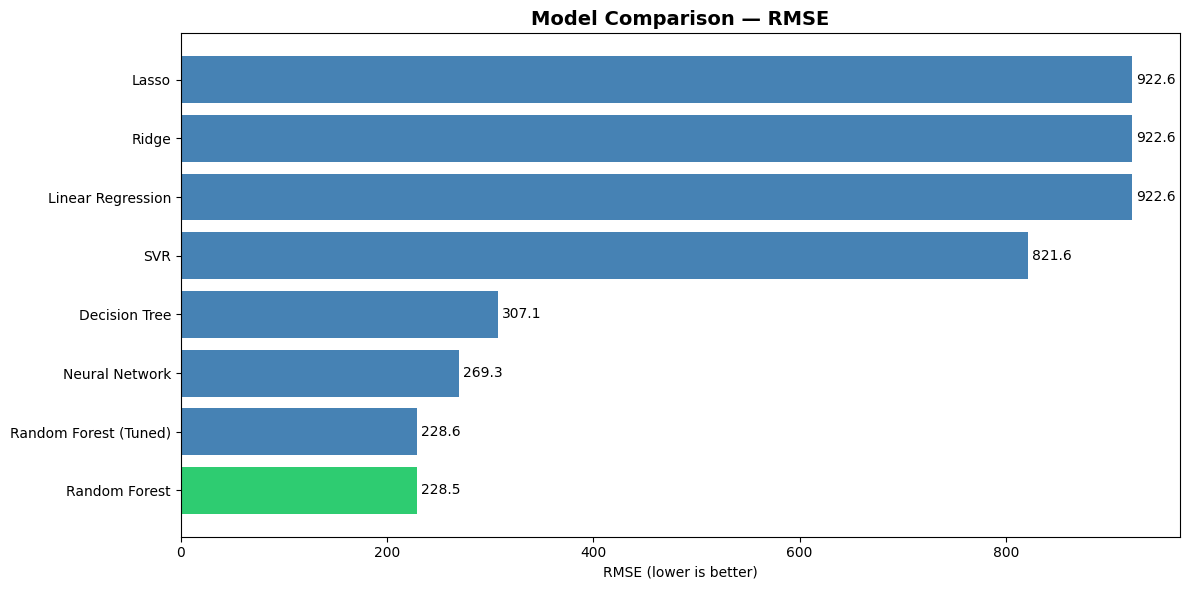

RMSE chart saved! ✓


In [37]:
rmse_sorted = results_df['RMSE'].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if i == 0 else 'steelblue' for i in range(len(rmse_sorted))]
bars = ax.barh(rmse_sorted.index, rmse_sorted.values, color=colors)
ax.set_xlabel('RMSE (lower is better)')
ax.set_title('Model Comparison — RMSE', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='%.1f', padding=3)
plt.tight_layout()
plt.savefig('rmse_comparison.png', dpi=150)
plt.show()
print("RMSE chart saved! ✓")

display(HTML("""
<div style="background: linear-gradient(90deg, #0f0c29, #302b63, #24243e);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #00d2ff; margin: 0;">🎯 Step 8: Actual vs Predicted</h2>
    <p style="color: #a8dadc; margin: 8px 0 0 0;">
        Best Model: Tuned Random Forest
    </p>
</div>
"""))

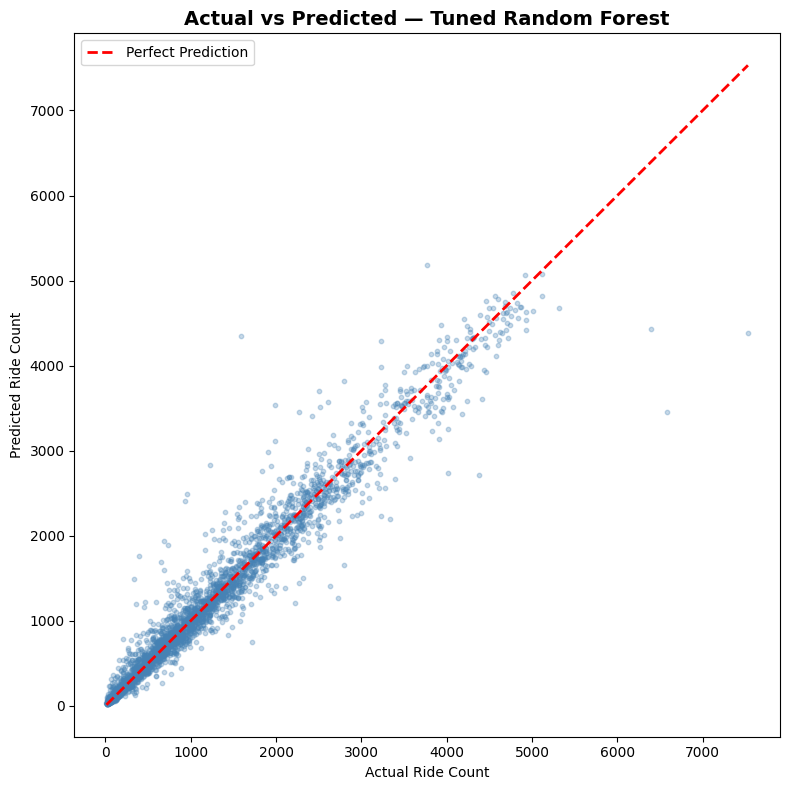

Actual vs Predicted chart saved! ✓


In [38]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_tuned, alpha=0.3, color='steelblue', s=10)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Ride Count')
ax.set_ylabel('Predicted Ride Count')
ax.set_title('Actual vs Predicted — Tuned Random Forest', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
print("Actual vs Predicted chart saved! ✓")

display(HTML("""
<div style="background: linear-gradient(90deg, #8e2de2, #4a00e0);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🏆 Step 9: Feature Importances</h2>
    <p style="color: #ddd; margin: 8px 0 0 0;">Tuned Random Forest</p>
</div>
"""))

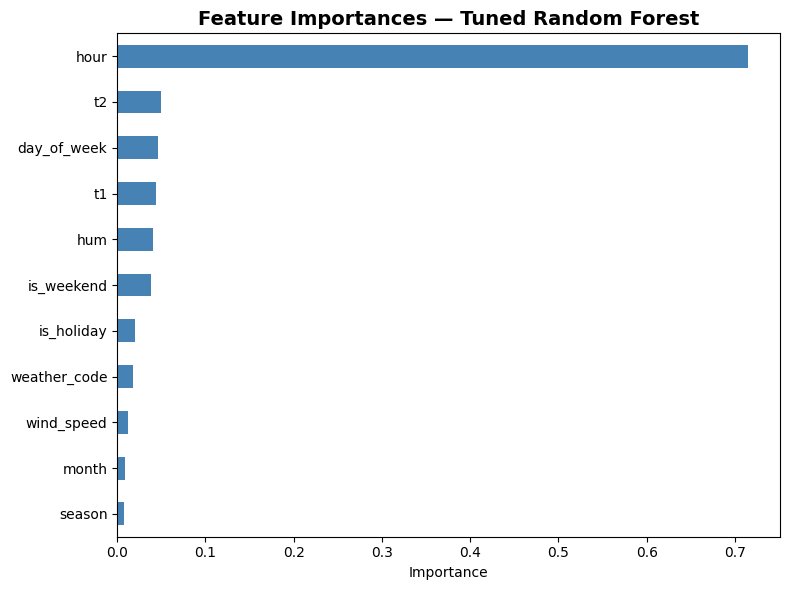

Feature importances saved! ✓


In [39]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances — Tuned Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importances_regression.png', dpi=150)
plt.show()
print("Feature importances saved! ✓")

display(HTML("""
<div style="background: linear-gradient(135deg, #0f2027, #203a43);
            padding: 30px; border-radius: 15px; margin-top: 20px; border: 2px solid #00d2ff;">
    <h2 style="color: #00d2ff; margin-top: 0;">✅ Step 10: Conclusion</h2>
    <h3 style="color: #38ef7d;">Best Model: Tuned Random Forest 🏆</h3>
    <p style="color: #a8dadc; line-height: 1.8;">
        The <b style="color:#ffd200;">Tuned Random Forest</b> achieved the lowest RMSE
        among all models, making it the best choice for predicting hourly bike ride counts.
        It captures complex non-linear relationships between weather, time features, and demand
        far better than linear models (Linear Regression, Lasso, Ridge). Feature importance
        analysis confirms that <b style="color:#00d2ff;">hour of day</b> is the dominant
        predictor, followed by <b style="color:#00d2ff;">humidity</b> and
        <b style="color:#00d2ff;">temperature</b>. GridSearchCV tuning further reduced
        RMSE over the default baseline by optimising tree depth and ensemble size.
    </p>
</div>
"""))